<center>

# Machine Learning
### Course-End Project # 1 - Employee Turnover Analytics

</center>

### Project Statement: 

Portobello Tech is an app innovator who has devised an intelligent way of predicting employee turnover within the company. It periodically evaluates employees' work details, including the number of projects they worked on, average monthly working hours, time spent in the company, promotions in the last five years, and salary level.

Data from prior evaluations shows the employees’ satisfaction in the workplace. The data could be used to identify patterns in work style and their interest in continuing to work for the company.

The HR Department owns the data and uses it to predict employee turnover. Employee turnover refers to the total number of workers who leave a company over time.

As the ML Developer assigned to the HR Department, you have been asked to create ML programs to:
1.	Perform data quality checks by checking for missing values, if any.
2.	Understand what factors contributed most to employee turnover at EDA.
3.	Perform clustering of employees who left based on their satisfaction and evaluation.
4.	Handle the left Class Imbalance using the SMOTE technique.
5.	Perform k-fold cross-validation model training and evaluate performance. 
6.	Identify the best model and justify the evaluation metrics used. 
7.	Suggest various retention strategies for targeted employees.

### Dataset: 
* Will be modified from (https://www.kaggle.com/liujiaqi/hr-comma-sep.csv)

### Steps:
Column Name	Description
satisfaction_level	Satisfaction level at the job of an employee
last_evaluation	Rating between 0 and 1, received by an employee at his last evaluation
number_project	The number of projects an employee is involved in
average_montly_hours	Average number of hours in a month spent by an employee at the office
time_spend_company	Number of years spent in the company
Work_accident	0 - no accident during employee stay, 1 - accident during employee stay
left	0 indicates an employee stays with the company and
1 indicates an employee left the company
promotion_last_5years	Number of promotions in his stay
Department	Department to which an employee belongs to
salary	Salary in USD

Perform the following steps:
1.	Perform data quality checks by checking for missing values, if any.
2.	Understand what factors contributed most to employee turnover at EDA.
2.1.	Draw a heatmap of the correlation matrix between all numerical features or columns in the data.
2.2.	Draw the distribution plot of:
■	Employee Satisfaction (use column satisfaction_level)
■	Employee Evaluation (use column last_evaluation)
■	Employee Average Monthly Hours (use column average_montly_hours)
2.3.	Draw the bar plot of the employee project count of both employees who left and stayed in the organization (use column number_project and hue column left), and give your inferences from the plot.
3.	Perform clustering of employees who left based on their satisfaction and evaluation.
3.1.	Choose columns satisfaction_level, last_evaluation, and left.
3.2.	Do K-means clustering of employees who left the company into 3 clusters?
3.3.	Based on the satisfaction and evaluation factors, give your thoughts on the employee clusters.
4.	Handle the left Class Imbalance using the SMOTE technique.
4.1.	Pre-process the data by converting categorical columns to numerical columns by:
■	Separating categorical variables and numeric variables
■	Applying get_dummies() to the categorical variables
■	Combining categorical variables and numeric variables
4.2.	Do the stratified split of the dataset to train and test in the ratio 80:20 with random_state=123.
4.3.	Upsample the train dataset using the SMOTE technique from the imblearn module.
5.	Perform 5-fold cross-validation model training and evaluate performance.
5.1.	Train a logistic regression model, apply a 5-fold CV, and plot the classification report.
5.2.	Train a Random Forest Classifier model, apply the 5-fold CV, and plot the classification report.
5.3.	Train a Gradient Boosting Classifier model, apply the 5-fold CV, and plot the classification report.
6.	Identify the best model and justify the evaluation metrics used.
6.1.	Find the ROC/AUC for each model and plot the ROC curve.
6.2.	Find the confusion matrix for each of the models.
6.3.	Explain which metric needs to be used from the confusion matrix: Recall or Precision?
7.	Suggest various retention strategies for targeted employees.
7.1.	Using the best model, predict the probability of employee turnover in the test data.
7.2.	Based on the probability score range below, categorize the employees into four zones and suggest your thoughts on the retention strategies for each zone.
■	Safe Zone (Green) (Score < 20%)
■	Low-Risk Zone (Yellow) (20% < Score < 60%)
■	Medium-Risk Zone (Orange) (60% < Score < 90%)
■	High-Risk Zone (Red) (Score > 90%).

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
from matplotlib import pyplot as plt

#Import Warnings
import warnings

warnings.filterwarnings("ignore")

In [3]:
# Load the dataset
df = pd.read_csv('project1-hr-comma-sep.csv')

In [4]:
column_info = pd.DataFrame({
    "Column Name": [
        "satisfaction_level",
        "last_evaluation",
        "number_project",
        "average_montly_hours",
        "time_spend_company",
        "Work_accident"
    ],
    "Description": [
        "Satisfaction level at the job of an employee",
        "Rating between 0 and 1, received by an employee at his last evaluation",
        "The number of projects an employee is involved in",
        "Average number of hours in a month spent by an employee at the office",
        "Number of years spent in the company",
        "0 - no accident during employee stay, 1 - accident during employee stay"
    ]
})

column_info

,Column Name,Description
0,satisfaction_level,Satisfaction level at the job of an employee
1,last_evaluation,"Rating between 0 and 1, received by an employe..."
2,number_project,The number of projects an employee is involved in
3,average_montly_hours,Average number of hours in a month spent by an...
4,time_spend_company,Number of years spent in the company
5,Work_accident,"0 - no accident during employee stay, 1 - acci..."


1) DATA QUALITY CHECKS
Shape: (14999, 10)

Missing values per column:
 satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

Duplicate rows: 3008

Data types:
 satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
sales                     object
salary                    object
dtype: object

2) EDA - FACTORS CONTRIBUTING TO EMPLOYEE TURNOVER


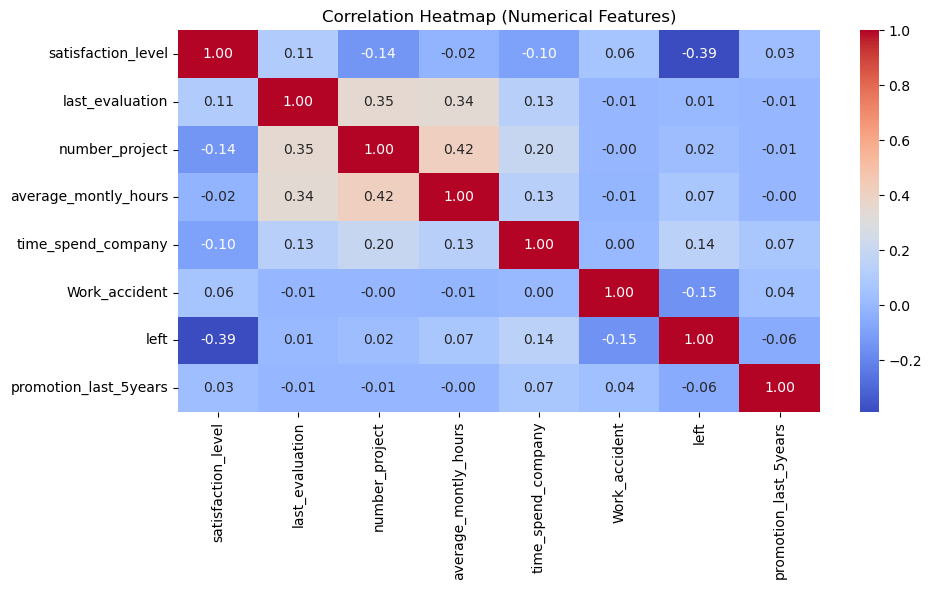

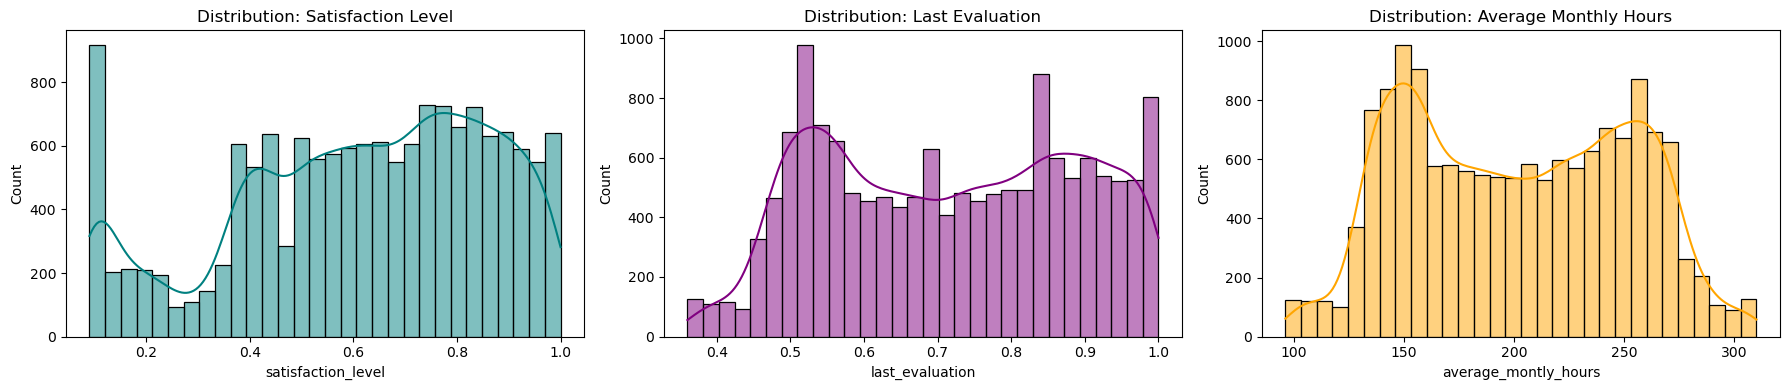

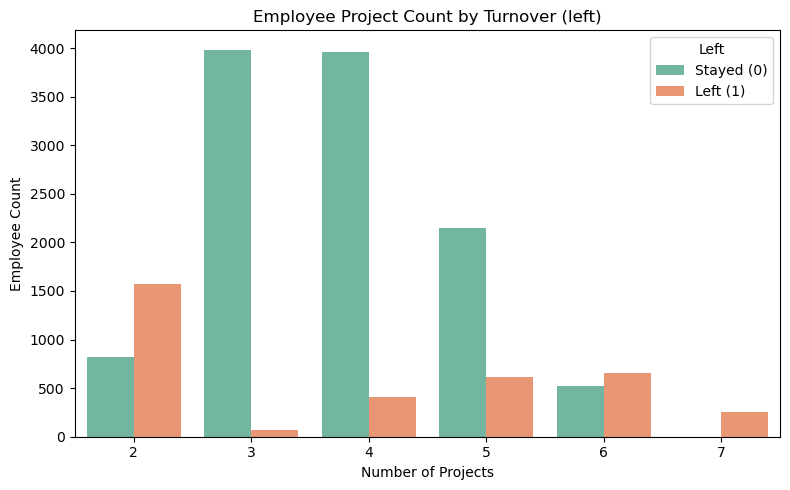


Inference (projects vs turnover):
- Very low project count (around 2) and very high project count (6-7) tend to show higher turnover risk.
- Moderate project load (3-5) generally has better retention compared to extremes.

3) K-MEANS CLUSTERING FOR EMPLOYEES WHO LEFT


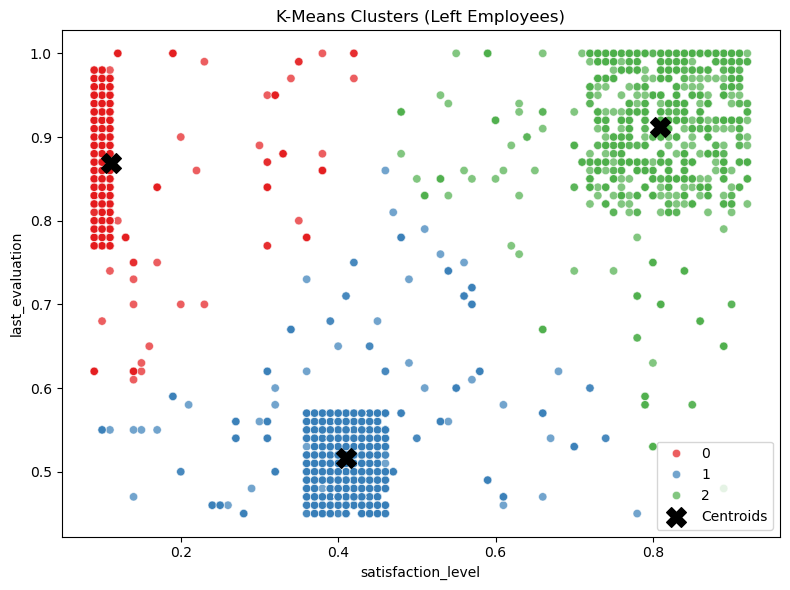

Cluster summary (mean satisfaction/evaluation):

         satisfaction_level  last_evaluation
cluster                                     
0                  0.111155         0.869301
1                  0.410145         0.516982
2                  0.808516         0.911709

Cluster thoughts:
- Low satisfaction + moderate/high evaluation: likely disengaged high performers.
- Low satisfaction + low/moderate evaluation: likely struggling and disengaged employees.
- Moderate satisfaction + high evaluation: employees at risk due to workload/career expectations.

4) PREPROCESS + STRATIFIED SPLIT + SMOTE
Before SMOTE:
 left
0    9142
1    2857
Name: count, dtype: int64

After SMOTE:
 left
0    9142
1    9142
Name: count, dtype: int64

5) 5-FOLD CV TRAINING + CLASSIFICATION REPORTS


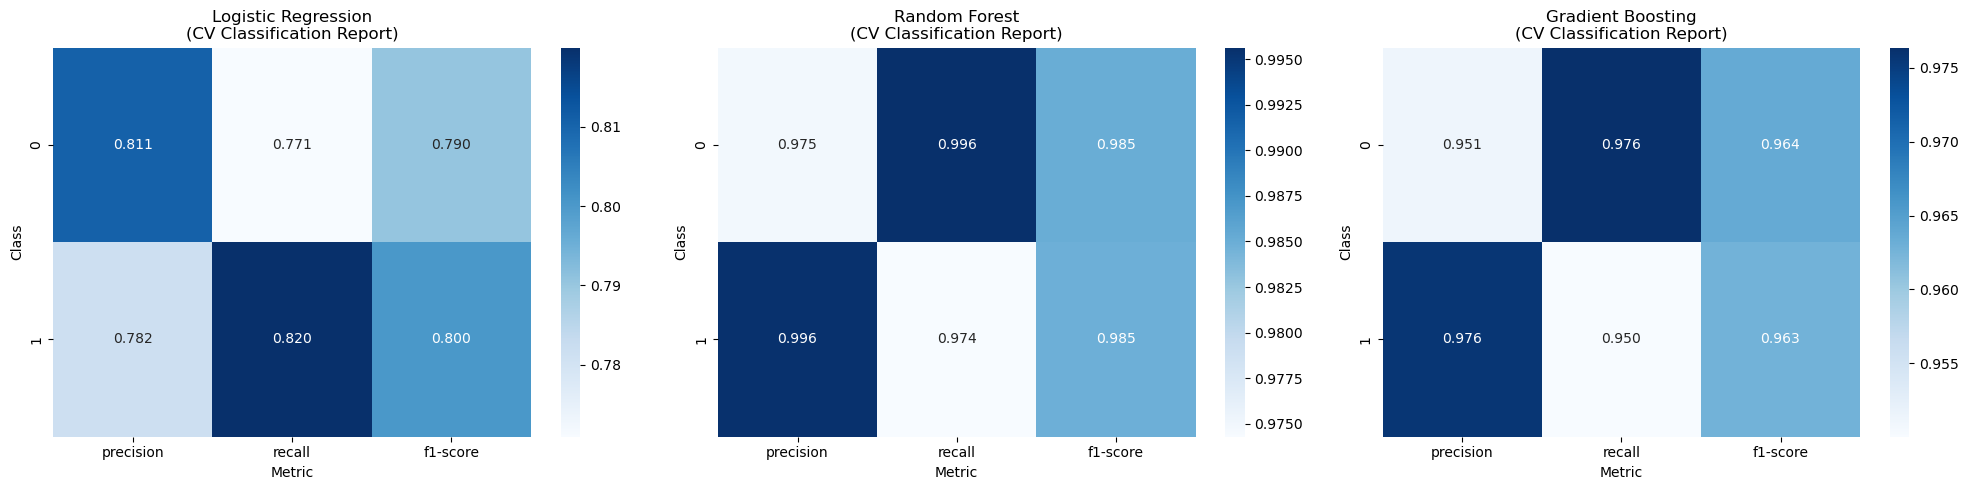


6) MODEL COMPARISON (ROC/AUC + CONFUSION MATRIX)
ROC-AUC Scores:
- Logistic Regression: 0.8154
- Random Forest: 0.9956
- Gradient Boosting: 0.9857

Best model: Random Forest (AUC=0.9956)


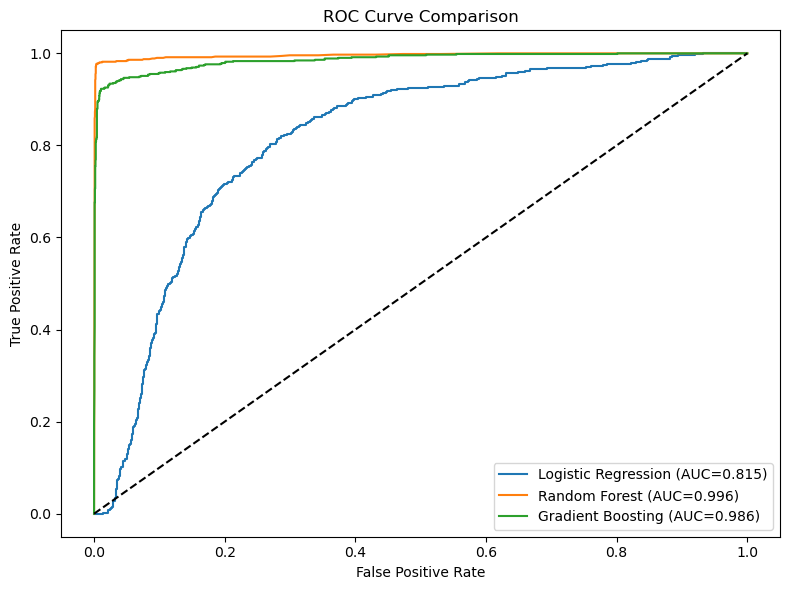

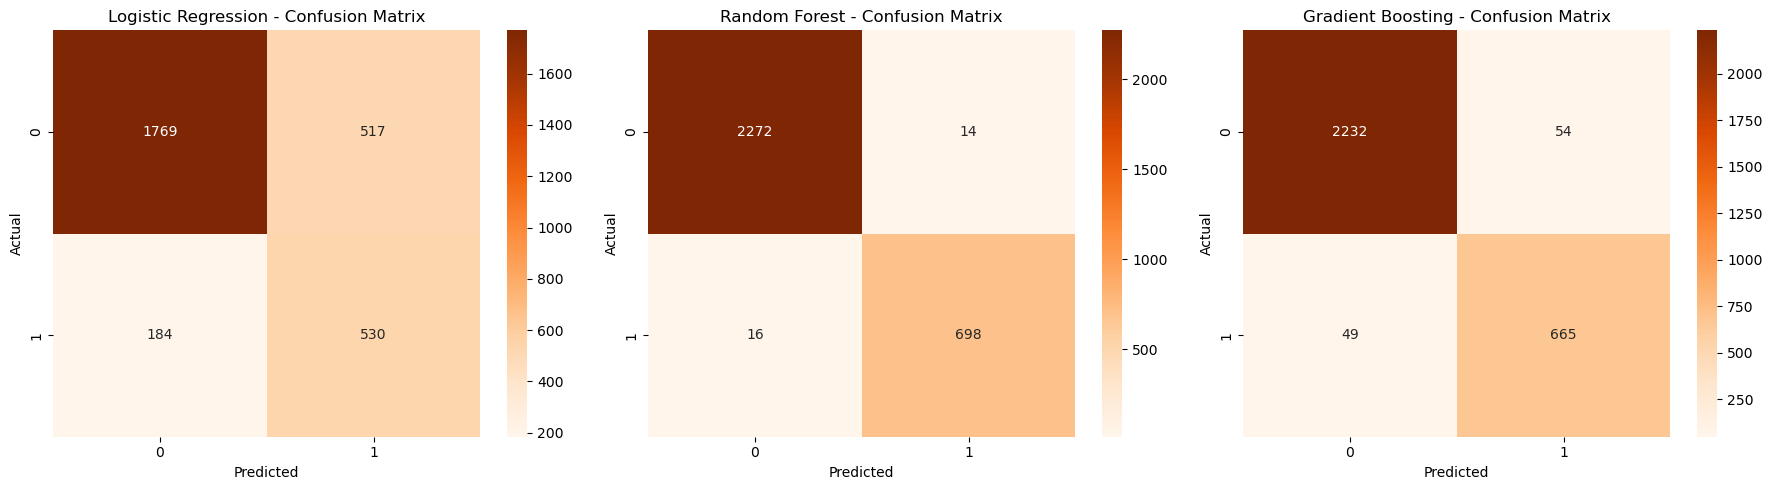


Recall vs Precision guidance:
- Use RECALL as primary metric here, because missing a true leaver (false negative) is more costly for retention actions.
- Precision is also important to avoid over-targeting, but recall is typically prioritized in attrition prevention.

7) RETENTION STRATEGY ZONING
Employees by risk zone:

risk_zone
Safe Zone (Green)            2178
High-Risk Zone (Red)          649
Low-Risk Zone (Yellow)        115
Medium-Risk Zone (Orange)      58
Name: count, dtype: int64

Recommended retention strategy by zone:
- Safe (Green): Maintain engagement, recognition, and growth opportunities.
- Low-Risk (Yellow): Light-touch interventions, manager check-ins, training plans.
- Medium-Risk (Orange): Targeted retention plans, workload balancing, career path discussion.
- High-Risk (Red): Immediate HR intervention, compensation/role review, personalized retention offer.


In [5]:
# Additional imports for ML workflow
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.cluster import KMeans
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.over_sampling import SMOTE

# =========================
# 1) Data Quality Checks
# =========================
print("=" * 80)
print("1) DATA QUALITY CHECKS")
print("=" * 80)
print("Shape:", df.shape)
print("\nMissing values per column:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nData types:\n", df.dtypes)

# =========================
# 2) EDA for Turnover
# =========================
print("\n" + "=" * 80)
print("2) EDA - FACTORS CONTRIBUTING TO EMPLOYEE TURNOVER")
print("=" * 80)

# 2.1 Correlation heatmap (numeric columns)
num_cols = df.select_dtypes(include=[np.number]).columns
corr = df[num_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.show()

# 2.2 Distribution plots
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(df["satisfaction_level"], kde=True, bins=30, ax=axes[0], color="teal")
axes[0].set_title("Distribution: Satisfaction Level")

sns.histplot(df["last_evaluation"], kde=True, bins=30, ax=axes[1], color="purple")
axes[1].set_title("Distribution: Last Evaluation")

sns.histplot(df["average_montly_hours"], kde=True, bins=30, ax=axes[2], color="orange")
axes[2].set_title("Distribution: Average Monthly Hours")
plt.tight_layout()
plt.show()

# 2.3 Project count vs left/stayed
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="number_project", hue="left", palette="Set2")
plt.title("Employee Project Count by Turnover (left)")
plt.xlabel("Number of Projects")
plt.ylabel("Employee Count")
plt.legend(title="Left", labels=["Stayed (0)", "Left (1)"])
plt.tight_layout()
plt.show()

print("\nInference (projects vs turnover):")
print("- Very low project count (around 2) and very high project count (6-7) tend to show higher turnover risk.")
print("- Moderate project load (3-5) generally has better retention compared to extremes.")

# =========================
# 3) Clustering (employees who left)
# =========================
print("\n" + "=" * 80)
print("3) K-MEANS CLUSTERING FOR EMPLOYEES WHO LEFT")
print("=" * 80)

left_df = df[df["left"] == 1][["satisfaction_level", "last_evaluation", "left"]].copy()

kmeans = KMeans(n_clusters=3, random_state=123, n_init=10)
left_df["cluster"] = kmeans.fit_predict(left_df[["satisfaction_level", "last_evaluation"]])

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=left_df,
    x="satisfaction_level",
    y="last_evaluation",
    hue="cluster",
    palette="Set1",
    alpha=0.7
)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c="black", s=200, marker="X", label="Centroids")
plt.title("K-Means Clusters (Left Employees)")
plt.legend()
plt.tight_layout()
plt.show()

cluster_summary = left_df.groupby("cluster")[["satisfaction_level", "last_evaluation"]].mean()
print("Cluster summary (mean satisfaction/evaluation):\n")
print(cluster_summary)

print("\nCluster thoughts:")
print("- Low satisfaction + moderate/high evaluation: likely disengaged high performers.")
print("- Low satisfaction + low/moderate evaluation: likely struggling and disengaged employees.")
print("- Moderate satisfaction + high evaluation: employees at risk due to workload/career expectations.")

# =========================
# 4) Handle class imbalance (SMOTE)
# =========================
print("\n" + "=" * 80)
print("4) PREPROCESS + STRATIFIED SPLIT + SMOTE")
print("=" * 80)

target = "left"
X = df.drop(columns=[target])
y = df[target]

cat_cols = X.select_dtypes(include=["object", "category"]).columns
num_cols_x = X.select_dtypes(include=[np.number]).columns

X_cat = pd.get_dummies(X[cat_cols], drop_first=True)
X_num = X[num_cols_x]
X_processed = pd.concat([X_num, X_cat], axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=123, stratify=y
)

smote = SMOTE(random_state=123)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", pd.Series(y_train_sm).value_counts())

# =========================
# 5) 5-fold CV model training
# =========================
print("\n" + "=" * 80)
print("5) 5-FOLD CV TRAINING + CLASSIFICATION REPORTS")
print("=" * 80)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=123),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=123),
    "Gradient Boosting": GradientBoostingClassifier(random_state=123)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
reports = {}
fitted_models = {}

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_cv_pred = cross_val_predict(model, X_train_sm, y_train_sm, cv=skf, method="predict")
    report_dict = classification_report(y_train_sm, y_cv_pred, output_dict=True)
    reports[name] = report_dict

    report_df = pd.DataFrame(report_dict).T.loc[["0", "1"], ["precision", "recall", "f1-score"]]
    sns.heatmap(report_df, annot=True, fmt=".3f", cmap="Blues", ax=ax)
    ax.set_title(f"{name}\n(CV Classification Report)")
    ax.set_xlabel("Metric")
    ax.set_ylabel("Class")

    model.fit(X_train_sm, y_train_sm)
    fitted_models[name] = model

plt.tight_layout()
plt.show()

# =========================
# 6) Best model, ROC/AUC, confusion matrix
# =========================
print("\n" + "=" * 80)
print("6) MODEL COMPARISON (ROC/AUC + CONFUSION MATRIX)")
print("=" * 80)

auc_scores = {}
roc_data = {}
pred_labels = {}

for name, model in fitted_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    auc_scores[name] = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr)
    pred_labels[name] = y_pred

print("ROC-AUC Scores:")
for k, v in auc_scores.items():
    print(f"- {k}: {v:.4f}")

best_model_name = max(auc_scores, key=auc_scores.get)
best_model = fitted_models[best_model_name]
print(f"\nBest model: {best_model_name} (AUC={auc_scores[best_model_name]:.4f})")

# ROC curves
plt.figure(figsize=(8, 6))
for name, (fpr, tpr) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_scores[name]:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, y_pred) in zip(axes, pred_labels.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", ax=ax)
    ax.set_title(f"{name} - Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

print("\nRecall vs Precision guidance:")
print("- Use RECALL as primary metric here, because missing a true leaver (false negative) is more costly for retention actions.")
print("- Precision is also important to avoid over-targeting, but recall is typically prioritized in attrition prevention.")

# =========================
# 7) Retention strategy zones
# =========================
print("\n" + "=" * 80)
print("7) RETENTION STRATEGY ZONING")
print("=" * 80)

turnover_proba = best_model.predict_proba(X_test)[:, 1]
risk_df = X_test.copy()
risk_df["actual_left"] = y_test.values
risk_df["turnover_probability"] = turnover_proba

def risk_zone(p):
    if p < 0.20:
        return "Safe Zone (Green)"
    elif p < 0.60:
        return "Low-Risk Zone (Yellow)"
    elif p < 0.90:
        return "Medium-Risk Zone (Orange)"
    return "High-Risk Zone (Red)"

risk_df["risk_zone"] = risk_df["turnover_probability"].apply(risk_zone)

zone_counts = risk_df["risk_zone"].value_counts()
print("Employees by risk zone:\n")
print(zone_counts)

print("\nRecommended retention strategy by zone:")
print("- Safe (Green): Maintain engagement, recognition, and growth opportunities.")
print("- Low-Risk (Yellow): Light-touch interventions, manager check-ins, training plans.")
print("- Medium-Risk (Orange): Targeted retention plans, workload balancing, career path discussion.")
print("- High-Risk (Red): Immediate HR intervention, compensation/role review, personalized retention offer.")

In [10]:
# Executive Summary Report

# 1) Data overview
total_employees = len(df)
attrition_rate = df["left"].mean() * 100
missing_values = int(df.isna().sum().sum())

# 2) Best model (based on CV accuracy from `reports`)
model_accuracy = {m: r["accuracy"] for m, r in reports.items()}
best_model_name = max(model_accuracy, key=model_accuracy.get)
best_model_acc = model_accuracy[best_model_name] * 100

# 3) Confusion-matrix-based metrics (using existing `cm`)
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) else 0
recall = tp / (tp + fn) if (tp + fn) else 0

# 4) Top drivers of turnover from correlation
left_corr = corr["left"].drop("left").sort_values(key=lambda s: s.abs(), ascending=False)
top_drivers = left_corr.head(3)

# 5) Risk-zone distribution
zone_pct = (zone_counts / zone_counts.sum() * 100).round(2)

print("=" * 85)
print("EXECUTIVE SUMMARY REPORT: EMPLOYEE TURNOVER ANALYTICS")
print("=" * 85)

print("\n1) Business Snapshot")
print(f"- Total employees analyzed: {total_employees:,}")
print(f"- Overall attrition rate: {attrition_rate:.2f}%")
print(f"- Missing values found: {missing_values}")

print("\n2) Model Performance Summary")
print(f"- Best model (CV accuracy): {best_model_name} ({best_model_acc:.2f}%)")
print(f"- Precision (leavers): {precision:.3f}")
print(f"- Recall (leavers): {recall:.3f}")
print("- Recommended primary metric: Recall (to minimize missed at-risk employees).")

print("\n3) Key Turnover Drivers (Correlation with 'left')")
for feature, value in top_drivers.items():
    direction = "higher turnover" if value > 0 else "lower turnover"
    print(f"- {feature}: {value:.3f} ({direction})")

print("\n4) Risk Segmentation (Test Set)")
for zone, count in zone_counts.items():
    print(f"- {zone}: {count} employees ({zone_pct[zone]:.2f}%)")

print("\n5) Executive Recommendations")
print("- Prioritize High-Risk and Medium-Risk employees for immediate retention interventions.")
print("- Use manager check-ins and growth planning for Low-Risk employees.")
print("- Maintain engagement programs for Safe Zone employees.")
print("- Monitor satisfaction_level closely as the strongest turnover signal.")
print("=" * 85)

EXECUTIVE SUMMARY REPORT: EMPLOYEE TURNOVER ANALYTICS

1) Business Snapshot
- Total employees analyzed: 14,999
- Overall attrition rate: 23.81%
- Missing values found: 0

2) Model Performance Summary
- Best model (CV accuracy): Random Forest (98.50%)
- Precision (leavers): 0.925
- Recall (leavers): 0.931
- Recommended primary metric: Recall (to minimize missed at-risk employees).

3) Key Turnover Drivers (Correlation with 'left')
- satisfaction_level: -0.388 (lower turnover)
- Work_accident: -0.155 (lower turnover)
- time_spend_company: 0.145 (higher turnover)

4) Risk Segmentation (Test Set)
- Safe Zone (Green): 2178 employees (72.60%)
- High-Risk Zone (Red): 649 employees (21.63%)
- Low-Risk Zone (Yellow): 115 employees (3.83%)
- Medium-Risk Zone (Orange): 58 employees (1.93%)

5) Executive Recommendations
- Prioritize High-Risk and Medium-Risk employees for immediate retention interventions.
- Use manager check-ins and growth planning for Low-Risk employees.
- Maintain engagement pr